In [2]:
# ===============================================
# Code Block 1 — Imports, Configuration, File Checks
# ===============================================

import os
import numpy as np
import pandas as pd

# Paths
IN_DIR  = "../data/processed"
IN_FILE = os.path.join(IN_DIR, "events_cleaned.csv")
OUT_FILE = os.path.join(IN_DIR, "case_features.csv")

# Check file exists
if not os.path.exists(IN_FILE):
    raise FileNotFoundError(f"ERROR: Missing cleaned events file:\n{IN_FILE}")

print("Input file found:", IN_FILE)

# Load data
events = pd.read_csv(IN_FILE, parse_dates=["timestamp"], low_memory=False)

print("\n--- Loaded events_cleaned.csv ---")
print("Shape:", events.shape)
display(events.head())


Input file found: ../data/processed\events_cleaned.csv

--- Loaded events_cleaned.csv ---
Shape: (262628, 14)


,case_id,timestamp,activity,resource,cost,municipality,case_status,case_procedure,event_id,all_properties,year,month,weekday,hour
0,10002463,2014-08-05 00:00:00+00:00,register submission date request,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":136730,""labels"":[""Event""],""properties"":{...",2014,8,1,0
1,10002463,2014-08-06 00:00:00+00:00,regular procedure without MER,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137411,""labels"":[""Event""],""properties"":{...",2014,8,2,0
2,10002463,2014-08-06 00:00:00+00:00,create procedure confirmation,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137412,""labels"":[""Event""],""properties"":{...",2014,8,2,0
3,10002463,2014-08-06 00:00:00+00:00,publish,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137413,""labels"":[""Event""],""properties"":{...",2014,8,2,0
4,10002463,2014-08-06 00:00:00+00:00,create subcases completeness,1550894,398.92447,BPIC15_4,O,Unknown,NaN,"{""id"":137414,""labels"":[""Event""],""properties"":{...",2014,8,2,0


In [3]:
# ===============================================
# Code Block 2 — Validate Required Columns
# ===============================================

required = ["case_id", "timestamp", "activity"]

missing = [c for c in required if c not in events.columns]
if missing:
    raise KeyError(f"ERROR: Missing required columns: {missing}")

print("All required columns present.")


All required columns present.


In [4]:
# ===============================================
# Code Block 3 — Confirm Sorted Order
# ===============================================

is_sorted = events.equals(
    events.sort_values(["case_id", "timestamp"]).reset_index(drop=True)
)

print("Events sorted by case_id + timestamp:", is_sorted)

if not is_sorted:
    print("Sorting again for safety...")
    events = events.sort_values(["case_id", "timestamp"]).reset_index(drop=True)


Events sorted by case_id + timestamp: True


In [5]:
# ===============================================
# Code Block 4 — Case Feature Extraction Function
# ===============================================

def compute_case_features(case_df):
    """Compute all required metrics for a single case."""
    
    case = {}
    case_id = case_df["case_id"].iloc[0]
    case["case_id"] = case_id
    
    # -----------------------------
    # 1. Extract basic timestamps
    # -----------------------------
    start = case_df["timestamp"].min()
    end   = case_df["timestamp"].max()
    
    case["case_start"] = start
    case["case_end"]   = end
    case["cycle_time_seconds"] = (end - start).total_seconds()
    
    # -----------------------------
    # 2. Event counts and structure
    # -----------------------------
    case["n_events"]            = len(case_df)
    case["n_unique_activities"] = case_df["activity"].nunique()
    case["n_unique_resources"]  = case_df["resource"].nunique() if "resource" in case_df else np.nan
    
    # -----------------------------
    # 3. Activity Sequence (Variant)
    # -----------------------------
    seq = case_df["activity"].astype(str).tolist()
    case["variant"] = "->".join(seq)
    case["variant_length"] = len(seq)
    
    # -----------------------------
    # 4. Rework (repeat activity detection)
    # -----------------------------
    from collections import Counter
    counts = Counter(seq)
    case["rework_count"] = sum(v - 1 for v in counts.values() if v > 1)
    
    # -----------------------------
    # 5. Cost
    # -----------------------------
    if "cost" in case_df:
        case["total_cost"] = pd.to_numeric(case_df["cost"], errors="coerce").sum()
    else:
        case["total_cost"] = np.nan
    
    # -----------------------------
    # 6. Wait time (gaps between events)
    # -----------------------------
    gaps = case_df["timestamp"].diff().dt.total_seconds().iloc[1:]
    case["wait_time_seconds"] = gaps.sum() if not gaps.empty else 0
    
    # Processing time ≈ cycle - wait
    case["processing_time_seconds"] = (
        case["cycle_time_seconds"] - case["wait_time_seconds"]
    )
    
    # -----------------------------
    # 7. Extract municipality
    # -----------------------------
    if "municipality" in case_df.columns:
        mun = case_df["municipality"].dropna().unique()
        case["municipality"] = mun[0] if len(mun) > 0 else np.nan
    else:
        case["municipality"] = np.nan
    
    # -----------------------------
    # 8. Case Status / Procedure
    # -----------------------------
    for field in ["case_status", "case_procedure"]:
        if field in case_df.columns:
            vals = case_df[field].dropna().unique()
            case[field] = vals[0] if len(vals) > 0 else np.nan
    
    return pd.Series(case)


In [6]:
# ===============================================
# Code Block 5 — Apply Case Feature Extraction
# ===============================================

print("\n--- Computing case features (this may take time) ---")

case_features = (
    events.groupby("case_id", sort=False)
          .apply(compute_case_features)
          .reset_index(drop=True)
)

print("\nCase feature computation complete.")
print("Shape:", case_features.shape)
display(case_features.head())



--- Computing case features (this may take time) ---

Case feature computation complete.
Shape: (3183, 16)


C:\Users\likhi\AppData\Local\Temp\ipykernel_19952\1090973927.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_case_features)


,case_id,case_start,case_end,cycle_time_seconds,n_events,n_unique_activities,n_unique_resources,variant,variant_length,rework_count,total_cost,wait_time_seconds,processing_time_seconds,municipality,case_status,case_procedure
0,10002463,2014-08-05 00:00:00+00:00,2014-10-07 11:55:52+00:00,5486152.0,46,44,1,register submission date request->regular proc...,46,2,18350.52562,5486152.0,0.0,BPIC15_4,O,Unknown
1,10003257,2014-08-05 00:00:00+00:00,2014-08-06 09:35:43+00:00,120943.0,13,13,1,register submission date request->OLO messagin...,13,0,0.00000,120943.0,0.0,BPIC15_4,G,Unknown
2,10009280,2014-04-11 00:00:00+00:00,2014-06-05 00:00:00+00:00,4752000.0,45,42,1,register submission date request->OLO messagin...,45,3,7069.18725,4752000.0,0.0,BPIC15_1,O,Unknown
3,10044881,2014-08-14 00:00:00+00:00,2014-08-14 12:00:38+00:00,43238.0,13,13,1,OLO messaging active->send confirmation receip...,13,0,0.00000,43238.0,0.0,BPIC15_4,G,Unknown
4,10051546,2014-04-17 00:00:00+00:00,2014-06-26 00:00:00+00:00,6048000.0,57,53,1,create procedure confirmation->create subcases...,57,4,94153.53480,6048000.0,0.0,BPIC15_1,O,Unknown


In [7]:
# ===============================================
# Code Block 6 — Convert Seconds → Hours
# ===============================================

time_cols = ["cycle_time_seconds", "wait_time_seconds", "processing_time_seconds"]

for col in time_cols:
    case_features[col.replace("_seconds", "_hours")] = (
        case_features[col] / 3600.0
    )

print("Time conversion complete.")
display(case_features[[c for c in case_features.columns if "hours" in c]].head())


Time conversion complete.


,cycle_time_hours,wait_time_hours,processing_time_hours
0,1523.931111,1523.931111,0.0
1,33.595278,33.595278,0.0
2,1320.000000,1320.000000,0.0
3,12.010556,12.010556,0.0
4,1680.000000,1680.000000,0.0


In [8]:
# ===============================================
# Code Block 7 — Sanity Checks
# ===============================================

print("\n--- Sanity Check: Cycle Time ---")
print(case_features["cycle_time_hours"].describe())

print("\n--- Sanity Check: Variant Length ---")
print(case_features["variant_length"].describe())

print("\n--- Sanity Check: Cost ---")
print(case_features["total_cost"].describe())



--- Sanity Check: Cycle Time ---
count     3183.000000
mean      2483.813900
std       2986.298801
min          0.000000
25%        898.420694
50%       1632.000000
75%       2865.520278
max      49968.000000
Name: cycle_time_hours, dtype: float64

--- Sanity Check: Variant Length ---
count      3183.000000
mean         82.509582
std        2018.592089
min           1.000000
25%          39.000000
50%          46.000000
75%          57.000000
max      113927.000000
Name: variant_length, dtype: float64

--- Sanity Check: Cost ---
count    3.183000e+03
mean     1.639466e+05
std      2.497257e+06
min     -1.206652e+05
25%      0.000000e+00
50%      1.020030e+04
75%      7.149606e+04
max      1.388826e+08
Name: total_cost, dtype: float64


In [9]:
# ===============================================
# Code Block 8 — Save Case-Level Features
# ===============================================

case_features.to_csv(OUT_FILE, index=False)

print(f"\nSaved case features to:\n{OUT_FILE}")
print("Final shape:", case_features.shape)



Saved case features to:
../data/processed\case_features.csv
Final shape: (3183, 19)


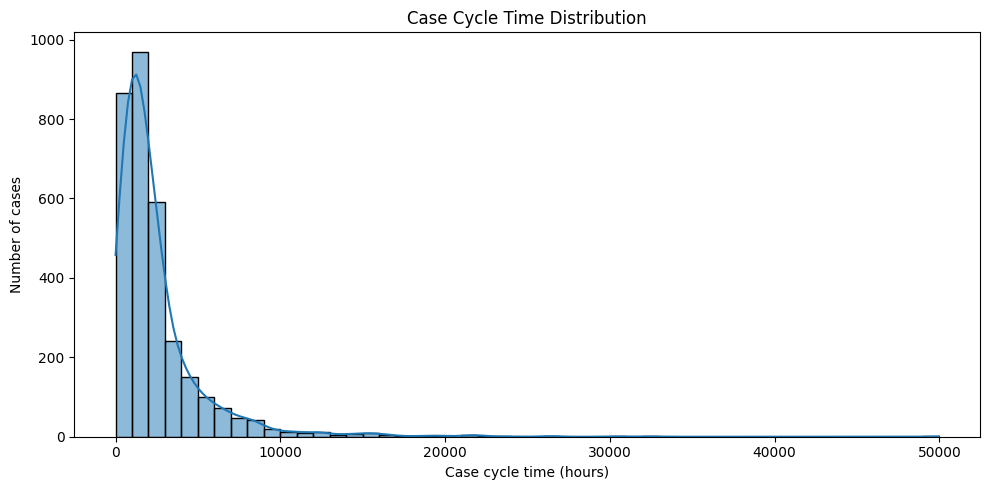

In [10]:
# Visualization — Case Cycle Time Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(
    data=case_features,
    x="cycle_time_hours",
    bins=50,
    kde=True
)
plt.xlabel("Case cycle time (hours)")
plt.ylabel("Number of cases")
plt.title("Case Cycle Time Distribution")
plt.tight_layout()
plt.show()

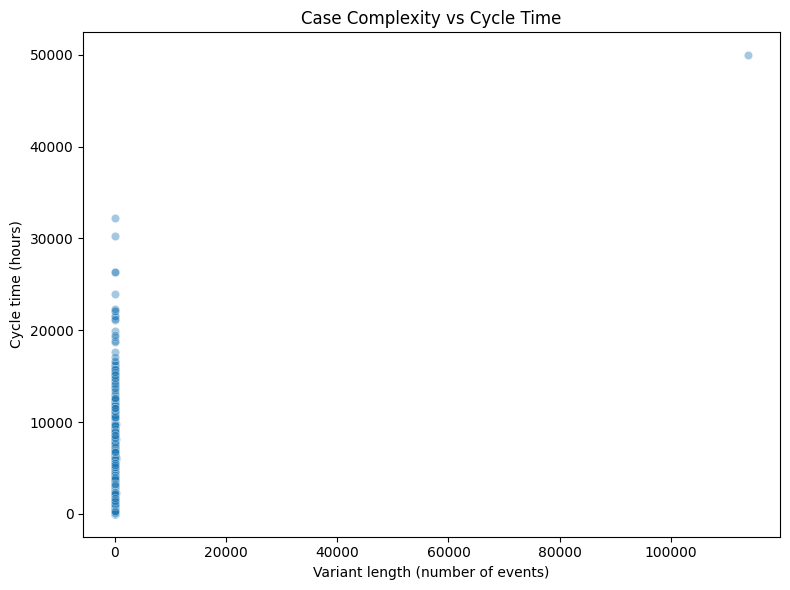

In [11]:
# Visualization — Case Complexity vs Cycle Time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=case_features,
    x="variant_length",          # case complexity proxy
    y="cycle_time_hours",
    alpha=0.4
)
plt.xlabel("Variant length (number of events)")
plt.ylabel("Cycle time (hours)")
plt.title("Case Complexity vs Cycle Time")
plt.tight_layout()
plt.show()